# Trabajo Final de Machine Learning

## Segundo avance: preparación y clasificación de tendencias financieras

Este notebook desarrolla una solución para analizar datos históricos del índice S&P 500. La primera parte aplica **Pandas** y **NumPy** para preparar los datos, mientras que la segunda implementa un problema de aprendizaje supervisado con **Scikit-learn** para clasificar la tendencia del siguiente día.

## Problemática

Una empresa de análisis financiero maneja grandes volúmenes de datos en archivos CSV, pero no cuenta con un procedimiento eficiente y reproducible para limpiarlos, analizarlos y prepararlos antes de aplicar Machine Learning. Esta situación dificulta la identificación de tendencias y la toma de decisiones basada en datos.

## Objetivo del avance

Preparar un dataset histórico del índice S&P 500 y construir un primer modelo de Machine Learning capaz de clasificar si el precio de cierre del siguiente día subirá o no. Para ello se aplican Pandas, NumPy y Scikit-learn, respetando el orden cronológico de la serie financiera.

### Alcance actual

- Lectura, exploración, limpieza y transformación del archivo CSV.
- Análisis estadístico con Pandas y NumPy.
- Creación de indicadores financieros derivados.
- Definición de las variables independientes X y la variable dependiente y.
- División cronológica entre entrenamiento y prueba.
- Entrenamiento de un modelo Random Forest.
- Evaluación con matriz de confusión, Accuracy, Precision, Recall y F1.
- Comparación con una predicción de referencia.

## 1. Importación de librerías

Se importan las librerías necesarias para manipular, analizar y visualizar los datos.

In [80]:
# Importa NumPy para realizar operaciones numéricas con vectores y matrices
import numpy as np

# Importa Pandas para trabajar con DataFrames y archivos CSV
import pandas as pd

# Importa Matplotlib y Seaborn para crear visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Configura el tamaño y estilo predeterminados de los gráficos
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2. Carga del dataset

El archivo se encuentra en la carpeta `data`, mientras que este notebook se ejecuta desde la carpeta `notebooks`. La clase `Path` permite construir y verificar la ruta antes de leer el CSV.

In [81]:
from pathlib import Path

# Define la ubicación del archivo original
ruta_archivo = Path("../data/snp500_history.csv")

# Detiene la ejecución con un mensaje claro si el archivo no existe
if not ruta_archivo.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo en: {ruta_archivo.resolve()}"
    )

# Lee el CSV y lo convierte en un DataFrame
df = pd.read_csv(ruta_archivo)

print("Archivo cargado:", ruta_archivo.resolve())
print("Dimensiones originales:", df.shape)

Archivo cargado: C:\Users\KarLoz\Documents\1-PROYECTOS\trabajo_final_machine_learning\data\snp500_history.csv
Dimensiones originales: (23970, 8)


## 3. Exploración inicial

La exploración permite conocer la estructura del dataset antes de modificarlo. Cada fila representa una fecha de negociación y cada columna contiene una característica financiera.

In [82]:
# Muestra una primera muestra del contenido
display(df.head(10))

# Informa la cantidad de filas, columnas y sus nombres
cantidad_filas, cantidad_columnas = df.shape
print("Cantidad de filas:", cantidad_filas)
print("Cantidad de columnas:", cantidad_columnas)
print("Columnas originales:", df.columns.tolist())

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1,1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
2,1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
3,1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
4,1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
5,1928-01-09 00:00:00-05:00,17.500000,17.500000,17.500000,17.500000,0,0.0,0.0
6,1928-01-10 00:00:00-05:00,17.370001,17.370001,17.370001,17.370001,0,0.0,0.0
7,1928-01-11 00:00:00-05:00,17.350000,17.350000,17.350000,17.350000,0,0.0,0.0
8,1928-01-12 00:00:00-05:00,17.469999,17.469999,17.469999,17.469999,0,0.0,0.0
9,1928-01-13 00:00:00-05:00,17.580000,17.580000,17.580000,17.580000,0,0.0,0.0


Cantidad de filas: 23970
Cantidad de columnas: 8
Columnas originales: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']


In [83]:
# Muestra los tipos de datos y la cantidad de valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23970 entries, 0 to 23969
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          23970 non-null  str    
 1   Open          23970 non-null  float64
 2   High          23970 non-null  float64
 3   Low           23970 non-null  float64
 4   Close         23970 non-null  float64
 5   Volume        23970 non-null  int64  
 6   Dividends     23970 non-null  float64
 7   Stock Splits  23970 non-null  float64
dtypes: float64(6), int64(1), str(1)
memory usage: 1.5 MB


## 4. Limpieza de datos

Se revisan valores nulos, registros duplicados, columnas sin nombre, fechas repetidas, precios inválidos y columnas que no presentan variación. Como se trata de una serie temporal, si existe un periodo antiguo con precios incompletos se conserva un tramo posterior continuo, evitando huecos extensos entre observaciones.

In [84]:
# Cuenta los valores nulos de cada columna
valores_nulos = df.isnull().sum()

if (valores_nulos > 0).any():
    print("Columnas con valores nulos:")
    display(valores_nulos[valores_nulos > 0])
else:
    print("El dataset no contiene valores nulos.")

El dataset no contiene valores nulos.


In [85]:
# Elimina filas completamente repetidas y registra el resultado
filas_antes = len(df)
df = df.drop_duplicates().copy()
filas_eliminadas = filas_antes - len(df)

print("Filas duplicadas eliminadas:", filas_eliminadas)

Filas duplicadas eliminadas: 0


In [86]:
# Elimina columnas auxiliares creadas al exportar otros DataFrames
columnas_sin_nombre = df.columns.str.contains(
    "^Unnamed",
    case=False,
    regex=True
)

df = df.loc[:, ~columnas_sin_nombre].copy()
print("Columnas después de eliminar nombres auxiliares:", df.columns.tolist())

Columnas después de eliminar nombres auxiliares: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']


In [87]:
# Convierte Date de texto a fecha y normaliza la zona horaria
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce",
    utc=True
).dt.tz_localize(None).dt.normalize()

# Elimina fechas que no pudieron convertirse
fechas_invalidas = df["Date"].isna().sum()
df = df.dropna(subset=["Date"]).copy()

# Ordena cronológicamente y elimina fechas repetidas
fechas_duplicadas = df.duplicated(subset=["Date"]).sum()
df = (
    df.sort_values("Date")
      .drop_duplicates(subset=["Date"], keep="last")
      .reset_index(drop=True)
)

print("Fechas inválidas eliminadas:", fechas_invalidas)
print("Fechas duplicadas eliminadas:", fechas_duplicadas)
print("Tipo de Date:", df["Date"].dtype)

Fechas inválidas eliminadas: 0
Fechas duplicadas eliminadas: 0
Tipo de Date: datetime64[us]


In [88]:
# Traduce los nombres para facilitar la lectura y exposición
df = df.rename(columns={
    "Date": "Fecha",
    "Open": "Apertura",
    "High": "Maximo",
    "Low": "Minimo",
    "Close": "Cierre",
    "Volume": "Volumen",
    "Dividends": "Dividendos",
    "Stock Splits": "Division_Acciones"
})

print("Columnas traducidas:", df.columns.tolist())

Columnas traducidas: ['Fecha', 'Apertura', 'Maximo', 'Minimo', 'Cierre', 'Volumen', 'Dividendos', 'Division_Acciones']


In [89]:
# Comprueba que los precios financieros sean mayores que cero
columnas_precios = ["Apertura", "Maximo", "Minimo", "Cierre"]
conteo_precios_invalidos = (df[columnas_precios] <= 0).sum()

print("Valores menores o iguales a cero por columna:")
display(conteo_precios_invalidos)

# Identifica las filas que tienen al menos un precio inválido
mascara_precios_invalidos = (df[columnas_precios] <= 0).any(axis=1)
filas_con_precio_invalido = mascara_precios_invalidos.sum()

# Conserva un periodo cronológico continuo posterior al último precio inválido
if filas_con_precio_invalido > 0:
    ultima_fecha_incompleta = df.loc[
        mascara_precios_invalidos,
        "Fecha"
    ].max()

    df = (
        df.loc[df["Fecha"] > ultima_fecha_incompleta]
          .reset_index(drop=True)
          .copy()
    )

    print("Última fecha con precios incompletos:", ultima_fecha_incompleta)
else:
    df = df.reset_index(drop=True).copy()

print("Filas con precios inválidos detectadas:", filas_con_precio_invalido)
print("Periodo continuo seleccionado:", df["Fecha"].min(), "a", df["Fecha"].max())

Valores menores o iguales a cero por columna:


Apertura    5075
Maximo         0
Minimo         0
Cierre         0
dtype: int64

Última fecha con precios incompletos: 1982-04-19 00:00:00
Filas con precios inválidos detectadas: 5075
Periodo continuo seleccionado: 1982-04-20 00:00:00 a 2023-06-02 00:00:00


In [90]:
# Identifica columnas que contienen un único valor y no aportan variación
columnas_constantes = [
    columna
    for columna in df.columns
    if df[columna].nunique(dropna=False) <= 1
]

print("Columnas constantes eliminadas:", columnas_constantes)
df = df.drop(columns=columnas_constantes)

print("Dimensiones después de la limpieza:", df.shape)
display(df.head())

Columnas constantes eliminadas: ['Dividendos', 'Division_Acciones']
Dimensiones después de la limpieza: (10368, 6)


,Fecha,Apertura,Maximo,Minimo,Cierre,Volumen
0,1982-04-20,115.800003,117.139999,114.830002,115.440002,54610000
1,1982-04-21,115.480003,115.870003,115.300003,115.720001,57820000
2,1982-04-22,115.720001,117.250000,115.720001,117.190002,64470000
3,1982-04-23,118.019997,118.639999,117.190002,118.639999,71840000
4,1982-04-26,118.940002,119.330002,118.250000,119.260002,60500000


## 5. Transformación de datos

Se crean nuevas columnas mediante operaciones vectorizadas. El retorno diario representa la variación porcentual del cierre, mientras que el rango diario muestra la diferencia relativa entre el precio máximo y mínimo.

In [91]:
# Calcula la variación porcentual respecto al cierre anterior
df["Retorno_Diario"] = df["Cierre"].pct_change(fill_method=None)

# Calcula la amplitud diaria del precio respecto a la apertura
df["Rango_Diario"] = (
    (df["Maximo"] - df["Minimo"]) / df["Apertura"]
)

# Extrae el año para realizar una agrupación cronológica
df["Anio"] = df["Fecha"].dt.year

display(
    df[[
        "Fecha",
        "Apertura",
        "Maximo",
        "Minimo",
        "Cierre",
        "Volumen",
        "Retorno_Diario",
        "Rango_Diario"
    ]].head(10)
)

,Fecha,Apertura,Maximo,Minimo,Cierre,Volumen,Retorno_Diario,Rango_Diario
0,1982-04-20,115.800003,117.139999,114.830002,115.440002,54610000,NaN,0.019948
1,1982-04-21,115.480003,115.870003,115.300003,115.720001,57820000,0.002425,0.004936
2,1982-04-22,115.720001,117.250000,115.720001,117.190002,64470000,0.012703,0.013222
3,1982-04-23,118.019997,118.639999,117.190002,118.639999,71840000,0.012373,0.012286
4,1982-04-26,118.940002,119.330002,118.250000,119.260002,60500000,0.005226,0.009080
5,1982-04-27,119.070000,119.260002,117.730003,118.000000,56480000,-0.010565,0.012850
6,1982-04-28,117.830002,118.050003,116.940002,117.260002,50530000,-0.006271,0.009420
7,1982-04-29,116.400002,117.239998,116.110001,116.139999,51330000,-0.009551,0.009708
8,1982-04-30,116.209999,116.779999,116.070000,116.440002,48200000,0.002583,0.006110
9,1982-05-03,115.959999,116.820000,115.910004,116.820000,46490000,0.003263,0.007847


## 6. Análisis estadístico con Pandas

Las estadísticas descriptivas resumen la distribución, tendencia central y dispersión de las variables numéricas.

In [92]:
# Genera las estadísticas y transpone la tabla para facilitar su lectura
estadisticas = df.describe().T
display(estadisticas)

,count,mean,min,25%,50%,75%,max,std
Fecha,10368,2002-11-01 06:32:30,1982-04-20 00:00:00,1992-07-19 06:00:00,2002-10-28 12:00:00,2013-02-14 06:00:00,2023-06-02 00:00:00,NaN
Apertura,10368.0,1287.577445,102.419998,415.597496,1122.069946,1544.777466,4804.509766,1061.788124
Maximo,10368.0,1295.274208,103.010002,417.24749,1128.190002,1551.115021,4818.620117,1067.822552
Minimo,10368.0,1279.342101,102.199997,413.532509,1114.945007,1536.730042,4780.040039,1055.237474
Cierre,10368.0,1287.846211,102.419998,415.657509,1121.880005,1545.892548,4796.560059,1061.908154
Volumen,10368.0,2001529600.694444,14990000.0,222510000.0,1336150000.0,3585047500.0,11456230000.0,1897780298.809554
Retorno_Diario,10367.0,0.000414,-0.204669,-0.004512,0.000571,0.005713,0.1158,0.011438
Rango_Diario,10368.0,0.012377,0.0,0.006747,0.010048,0.015122,0.204705,0.009173
Anio,10368.0,2002.333912,1982.0,1992.0,2002.0,2013.0,2023.0,11.882142


In [93]:
# Resume el comportamiento financiero por año
resumen_anual = (
    df.groupby("Anio")
      .agg(
          Cierre_Promedio=("Cierre", "mean"),
          Volumen_Promedio=("Volumen", "mean"),
          Retorno_Promedio=("Retorno_Diario", "mean")
      )
)

print("Resumen de los últimos diez años disponibles:")
display(resumen_anual.tail(10))

Resumen de los últimos diez años disponibles:


,Cierre_Promedio,Volumen_Promedio,Retorno_Promedio
Anio,,,
2014,1931.376110,3.354783e+09,0.000454
2015,2061.067741,3.655629e+09,0.000019
2016,2094.651264,3.904086e+09,0.000395
2017,2449.076379,3.420175e+09,0.000716
2018,2746.214183,3.634743e+09,-0.000199
2019,2913.356380,3.558550e+09,0.001038
2020,3217.855849,4.922448e+09,0.000832
2021,4273.385635,4.417140e+09,0.000980
2022,4098.514748,4.617723e+09,-0.000745


## 7. Operaciones con NumPy

Pandas organiza los datos en un DataFrame. Después de la limpieza, NumPy permite extraer vectores y matrices numéricas de alto rendimiento que posteriormente podrán alimentar un algoritmo de Machine Learning.

In [94]:
# Convierte los retornos válidos en un vector de NumPy
vector_retornos = df["Retorno_Diario"].dropna().to_numpy()

print("Dimensiones del vector:", vector_retornos.shape)
print("Retorno promedio:", np.mean(vector_retornos))
print("Desviación estándar:", np.std(vector_retornos))
print("Retorno mínimo:", np.min(vector_retornos))
print("Retorno máximo:", np.max(vector_retornos))

Dimensiones del vector: (10367,)
Retorno promedio: 0.0004144603296136934
Desviación estándar: 0.0114373762928127
Retorno mínimo: -0.2046693079969436
Retorno máximo: 0.11580036951513706


In [95]:
# Extrae una matriz con las características financieras básicas
columnas_matriz = [
    "Apertura",
    "Maximo",
    "Minimo",
    "Cierre",
    "Volumen",
    "Retorno_Diario",
    "Rango_Diario"
]

matriz_financiera = (
    df[columnas_matriz]
    .dropna()
    .to_numpy()
)

print("Dimensiones de la matriz financiera:", matriz_financiera.shape)
print("Primeras cinco filas de la matriz:")
print(matriz_financiera[:5])

Dimensiones de la matriz financiera: (10367, 7)
Primeras cinco filas de la matriz:
[[ 1.15480003e+02  1.15870003e+02  1.15300003e+02  1.15720001e+02
   5.78200000e+07  2.42549180e-03  4.93591685e-03]
 [ 1.15720001e+02  1.17250000e+02  1.15720001e+02  1.17190002e+02
   6.44700000e+07  1.27030868e-02  1.32215586e-02]
 [ 1.18019997e+02  1.18639999e+02  1.17190002e+02  1.18639999e+02
   7.18400000e+07  1.23730431e-02  1.22860277e-02]
 [ 1.18940002e+02  1.19330002e+02  1.18250000e+02  1.19260002e+02
   6.05000000e+07  5.22591664e-03  9.08022372e-03]
 [ 1.19070000e+02  1.19260002e+02  1.17730003e+02  1.18000000e+02
   5.64800000e+07 -1.05651695e-02  1.28495741e-02]]


## 8. Visualización de datos

Las visualizaciones permiten reconocer la distribución de los retornos, la evolución histórica del índice y las relaciones entre las variables.

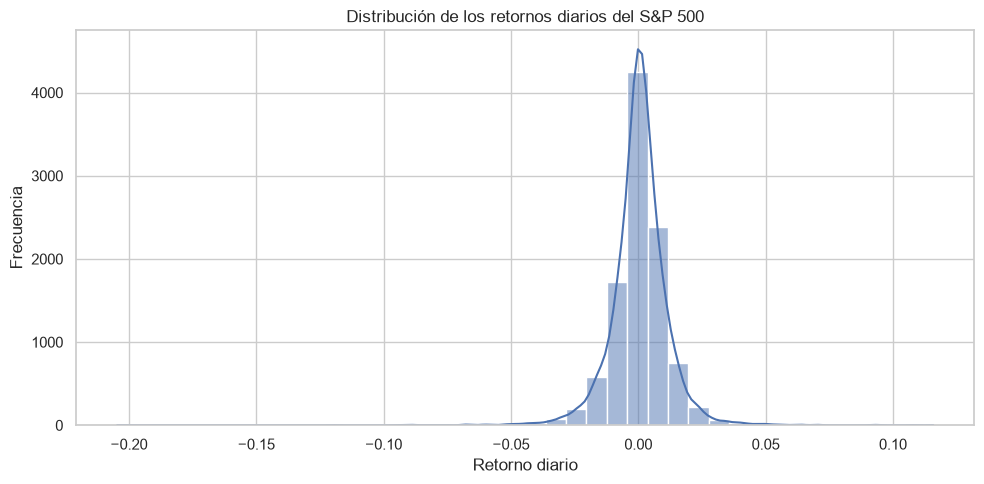

In [96]:
# Muestra la distribución de la variación porcentual diaria
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df.dropna(subset=["Retorno_Diario"]),
    x="Retorno_Diario",
    bins=40,
    kde=True
)

plt.title("Distribución de los retornos diarios del S&P 500")
plt.xlabel("Retorno diario")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

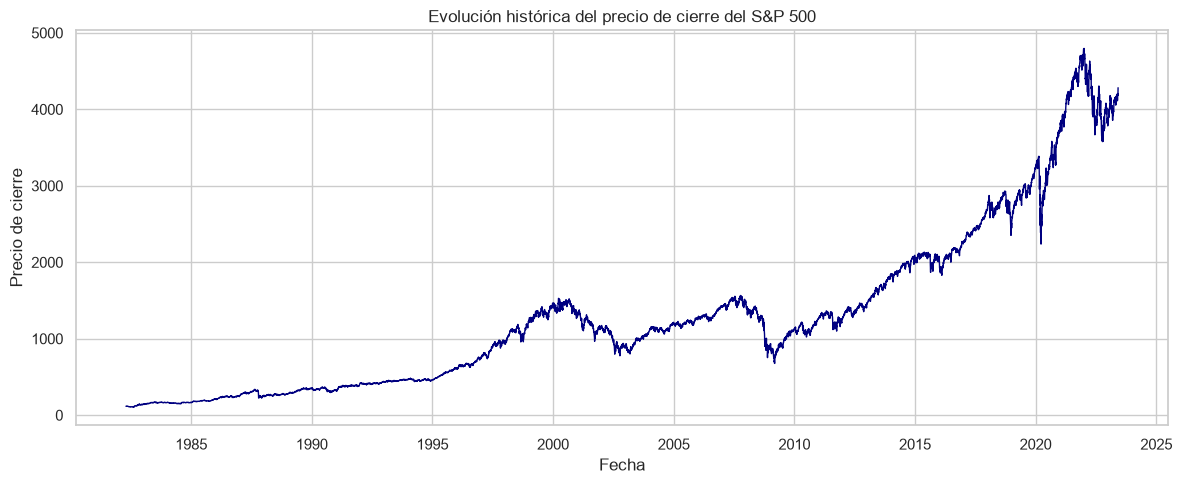

In [97]:
# Representa la evolución del precio de cierre
plt.figure(figsize=(12, 5))
plt.plot(df["Fecha"], df["Cierre"], color="navy", linewidth=1)

plt.title("Evolución histórica del precio de cierre del S&P 500")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.tight_layout()
plt.show()

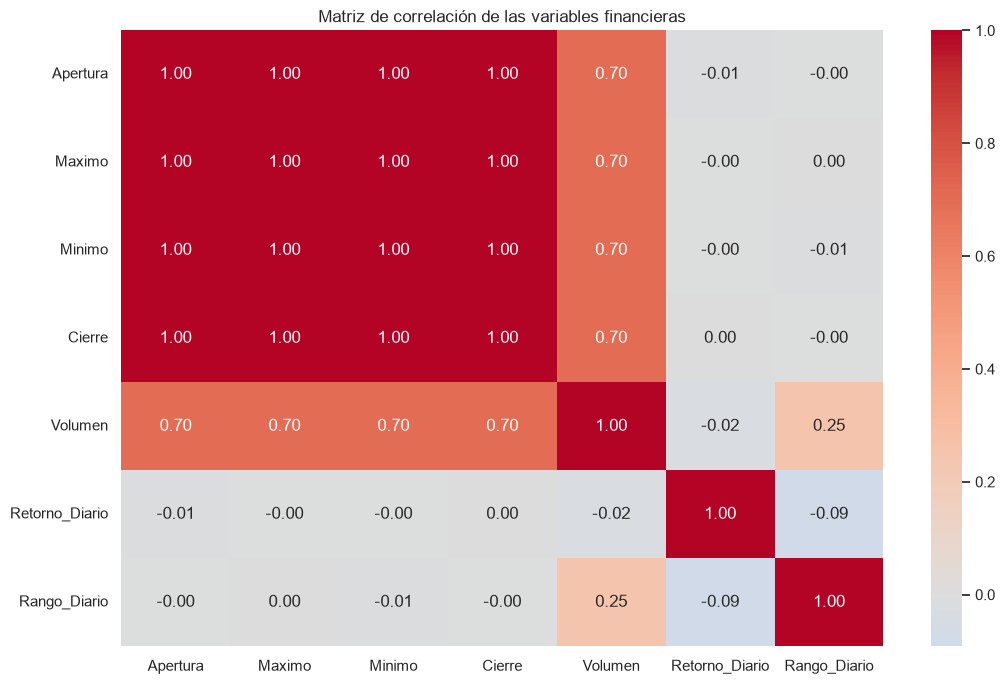

In [98]:
# Calcula y representa la correlación de las variables numéricas relevantes
columnas_correlacion = [
    "Apertura",
    "Maximo",
    "Minimo",
    "Cierre",
    "Volumen",
    "Retorno_Diario",
    "Rango_Diario"
]

matriz_correlacion = df[columnas_correlacion].corr()

plt.figure(figsize=(11, 7))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Matriz de correlación de las variables financieras")
plt.tight_layout()
plt.show()

## 9. Conclusiones de la preparación de datos

- El archivo original contiene **23,970 registros y 8 columnas**, sin valores nulos ni filas duplicadas.
- La columna de fecha fue convertida a un tipo temporal y las variables fueron traducidas al español.
- Se detectaron **5,075 aperturas con valor cero**, concentradas hasta el 19 de abril de 1982. Para evitar un hueco de veinte años se seleccionó un periodo continuo desde el 20 de abril de 1982 hasta el 2 de junio de 2023.
- Después de la limpieza quedaron **10,368 registros y 6 columnas originales útiles**. Dividendos y división de acciones fueron eliminadas por contener únicamente ceros.
- El retorno diario promedio fue aproximadamente **0.041 %**, con una desviación estándar de **1.144 %**.
- Se crearon el retorno y el rango diario mediante operaciones vectorizadas, y se extrajo una matriz de NumPy con **10,367 filas y 7 características numéricas**.
- Las visualizaciones muestran la concentración de los retornos alrededor de cero, el crecimiento histórico del índice y la fuerte correlación entre apertura, máximo, mínimo y cierre.

En el siguiente avance se definirán las variables independientes (X) y la variable dependiente (y), se dividirán cronológicamente los datos y se entrenará un primer modelo de clasificación con Scikit-learn.

# Parte II. Modelo de clasificación

## 10. Planteamiento del problema supervisado

El objetivo consiste en determinar si el cierre del siguiente día será mayor que el cierre actual. Como la respuesta solo puede pertenecer a dos categorías, se trata de un problema de **clasificación binaria supervisada**.

- Clase 1: el cierre del siguiente día sube.
- Clase 0: el cierre del siguiente día baja o se mantiene.

El modelo realizará la predicción después del cierre de cada jornada, utilizando solamente información disponible hasta ese día.

## 11. Creación de características financieras

Las variables originales se transforman en indicadores relativos. Esto evita que el modelo dependa únicamente del nivel nominal del índice, que ha cambiado considerablemente entre 1982 y 2023.

| Variable | Interpretación |
|---|---|
| Retorno_Diario | Variación porcentual del cierre respecto al día anterior |
| Rango_Diario | Diferencia relativa entre el máximo y el mínimo |
| Cambio_Intradiario | Variación entre la apertura y el cierre del mismo día |
| Cambio_Volumen | Variación porcentual del volumen negociado |
| Distancia_MM5 | Distancia del cierre respecto a la media de 5 días |
| Distancia_MM20 | Distancia del cierre respecto a la media de 20 días |
| Volatilidad_5 | Dispersión de los retornos durante 5 días |
| Volatilidad_20 | Dispersión de los retornos durante 20 días |

In [99]:
# Crea una copia específica para el modelo
df_ml = df.copy()

# Mide el cambio entre apertura y cierre del mismo día
df_ml["Cambio_Intradiario"] = (
    (df_ml["Cierre"] - df_ml["Apertura"])
    / df_ml["Apertura"]
)

# Mide la variación del volumen respecto al día anterior
df_ml["Cambio_Volumen"] = df_ml["Volumen"].pct_change(
    fill_method=None
)

# Calcula medias móviles de corto y mediano plazo
df_ml["Media_Movil_5"] = df_ml["Cierre"].rolling(5).mean()
df_ml["Media_Movil_20"] = df_ml["Cierre"].rolling(20).mean()

# Calcula la distancia relativa del cierre frente a las medias
df_ml["Distancia_MM5"] = (
    df_ml["Cierre"] / df_ml["Media_Movil_5"] - 1
)

df_ml["Distancia_MM20"] = (
    df_ml["Cierre"] / df_ml["Media_Movil_20"] - 1
)

# Calcula la volatilidad histórica de los retornos
df_ml["Volatilidad_5"] = (
    df_ml["Retorno_Diario"].rolling(5).std()
)

df_ml["Volatilidad_20"] = (
    df_ml["Retorno_Diario"].rolling(20).std()
)

display(
    df_ml[[
        "Fecha",
        "Retorno_Diario",
        "Cambio_Intradiario",
        "Cambio_Volumen",
        "Distancia_MM5",
        "Distancia_MM20",
        "Volatilidad_5",
        "Volatilidad_20"
    ]].tail(10)
)

,Fecha,Retorno_Diario,Cambio_Intradiario,Cambio_Volumen,Distancia_MM5,Distancia_MM20,Volatilidad_5,Volatilidad_20
10358,2023-05-19,-0.001446,-0.002895,0.015425,0.007931,0.015133,0.007548,0.009208
10359,2023-05-22,0.000155,0.000441,-0.077533,0.005363,0.014607,0.007682,0.009209
10360,2023-05-23,-0.011222,-0.007475,0.114469,-0.007618,0.002325,0.009261,0.008825
10361,2023-05-24,-0.007319,-0.004287,-0.100151,-0.012823,-0.005723,0.007894,0.008957
10362,2023-05-25,0.008758,-0.001066,0.109276,-0.001938,0.002791,0.007645,0.008042
10363,2023-05-26,0.013049,0.011860,-0.104225,0.010431,0.015436,0.010297,0.008360
10364,2023-05-30,0.000017,-0.005013,0.138085,0.009822,0.014991,0.010299,0.008358
10365,2023-05-31,-0.006109,-0.002603,0.414368,0.002006,0.008058,0.008997,0.008025
10366,2023-06-01,0.009854,0.009082,-0.265658,0.006774,0.016395,0.007916,0.008052
10367,2023-06-02,0.014534,0.009752,0.014194,0.015059,0.028430,0.008936,0.008265


## 12. Creación de la variable dependiente

La variable dependiente y será **Tendencia_Siguiente_Dia**. Para construirla se compara el cierre del día posterior con el cierre actual. La columna auxiliar Cierre_Siguiente se elimina después de crear la respuesta, para impedir que el modelo conozca anticipadamente el resultado.

In [100]:
# Obtiene temporalmente el cierre del día posterior
df_ml["Cierre_Siguiente"] = df_ml["Cierre"].shift(-1)

# Define las características que utilizará el modelo
variables_independientes = [
    "Retorno_Diario",
    "Rango_Diario",
    "Cambio_Intradiario",
    "Cambio_Volumen",
    "Distancia_MM5",
    "Distancia_MM20",
    "Volatilidad_5",
    "Volatilidad_20"
]

# Elimina filas incompletas generadas por medias, cambios y desplazamientos
df_ml = df_ml.dropna(
    subset=variables_independientes + ["Cierre_Siguiente"]
).copy()

# Crea la respuesta binaria: 1 si sube y 0 si no sube
df_ml["Tendencia_Siguiente_Dia"] = (
    df_ml["Cierre_Siguiente"] > df_ml["Cierre"]
).astype(int)

# Elimina la columna futura para evitar fuga de información
df_ml = df_ml.drop(columns=["Cierre_Siguiente"])

print("Registros disponibles para Machine Learning:", len(df_ml))
display(
    df_ml[[
        "Fecha",
        "Cierre",
        "Tendencia_Siguiente_Dia"
    ]].head(10)
)

Registros disponibles para Machine Learning: 10347


,Fecha,Cierre,Tendencia_Siguiente_Dia
20,1982-05-18,115.839996,0
21,1982-05-19,114.889999,0
22,1982-05-20,114.589996,1
23,1982-05-21,114.889999,0
24,1982-05-24,114.790001,0
25,1982-05-25,114.400002,0
26,1982-05-26,113.110001,0
27,1982-05-27,112.660004,0
28,1982-05-28,111.879997,0
29,1982-06-01,111.680000,1


## 13. Definición de X e y

X contiene las variables independientes o pistas conocidas por el modelo. La variable y contiene la respuesta que se desea predecir.

In [101]:
# Construye la matriz de características X
X = df_ml[variables_independientes]

# Construye el vector objetivo y
y = df_ml["Tendencia_Siguiente_Dia"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("\nVariables independientes:")
print(X.columns.tolist())

# Resume la cantidad y porcentaje de cada clase
distribucion_clases = pd.DataFrame({
    "Cantidad": y.value_counts().sort_index(),
    "Porcentaje": y.value_counts(
        normalize=True
    ).sort_index() * 100
})

distribucion_clases.index = ["No sube (0)", "Sube (1)"]
display(distribucion_clases)

Dimensiones de X: (10347, 8)
Dimensiones de y: (10347,)

Variables independientes:
['Retorno_Diario', 'Rango_Diario', 'Cambio_Intradiario', 'Cambio_Volumen', 'Distancia_MM5', 'Distancia_MM20', 'Volatilidad_5', 'Volatilidad_20']


,Cantidad,Porcentaje
No sube (0),4819,46.573886
Sube (1),5528,53.426114


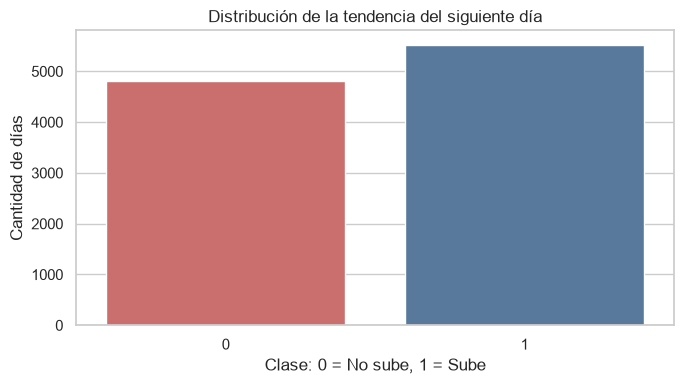

In [102]:
# Representa la distribución de la variable objetivo
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df_ml,
    x="Tendencia_Siguiente_Dia",
    hue="Tendencia_Siguiente_Dia",
    palette=["#d95f5f", "#4c78a8"],
    legend=False
)

plt.title("Distribución de la tendencia del siguiente día")
plt.xlabel("Clase: 0 = No sube, 1 = Sube")
plt.ylabel("Cantidad de días")
plt.tight_layout()
plt.show()

## 14. División cronológica de los datos

Se utiliza el primer 80 % de los registros para entrenamiento y el último 20 % para prueba. No se mezclan aleatoriamente las filas porque el modelo debe aprender con el pasado y evaluarse con información posterior.

In [103]:
# Calcula la posición que divide el 80 % y el 20 %
limite_entrenamiento = int(len(df_ml) * 0.80)

# Conserva el orden cronológico
X_train = X.iloc[:limite_entrenamiento]
X_test = X.iloc[limite_entrenamiento:]
y_train = y.iloc[:limite_entrenamiento]
y_test = y.iloc[limite_entrenamiento:]

# Guarda las fechas para interpretar la partición y los resultados
fechas_train = df_ml["Fecha"].iloc[:limite_entrenamiento]
fechas_test = df_ml["Fecha"].iloc[limite_entrenamiento:]

print("Registros de entrenamiento:", len(X_train))
print("Periodo de entrenamiento:", fechas_train.min(), "a", fechas_train.max())
print("\nRegistros de prueba:", len(X_test))
print("Periodo de prueba:", fechas_test.min(), "a", fechas_test.max())

Registros de entrenamiento: 8277
Periodo de entrenamiento: 1982-05-18 00:00:00 a 2015-03-12 00:00:00

Registros de prueba: 2070
Periodo de prueba: 2015-03-13 00:00:00 a 2023-06-01 00:00:00


## 15. Entrenamiento con Random Forest

Random Forest combina varios árboles de decisión. Se limita su profundidad y se exige una cantidad mínima de muestras por hoja para reducir el sobreajuste. El balanceo de clases evita favorecer automáticamente una tendencia. Para volver a ejecutar esta parte en el entorno virtual se requiere instalar Scikit-learn con `python -m pip install scikit-learn`.

In [104]:
from sklearn.ensemble import RandomForestClassifier

# Crea el modelo con una configuración reproducible
modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Entrena el modelo con los datos históricos
modelo_rf.fit(X_train, y_train)

# Genera predicciones para datos posteriores no vistos
y_pred = modelo_rf.predict(X_test)

print("Modelo entrenado y predicciones generadas correctamente.")

ModuleNotFoundError: No module named 'sklearn'

## 16. Evaluación del modelo

Las métricas comparan las predicciones con las tendencias reales:

- Accuracy: proporción total de aciertos.
- Precision: de las subidas predichas, cuántas realmente subieron.
- Recall: de todas las subidas reales, cuántas detectó el modelo.
- F1: equilibrio entre Precision y Recall.

También se crea una referencia que siempre predice la clase más frecuente. Esto permite comprobar si el modelo aporta algo más que repetir la tendencia mayoritaria.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Calcula las métricas del modelo
exactitud_train = accuracy_score(
    y_train,
    modelo_rf.predict(X_train)
)

exactitud = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Crea una predicción sencilla con la clase mayoritaria del entrenamiento
clase_mayoritaria = y_train.mode().iloc[0]
prediccion_referencia = np.full(
    len(y_test),
    clase_mayoritaria
)

exactitud_referencia = accuracy_score(
    y_test,
    prediccion_referencia
)

resultados_metricas = pd.DataFrame({
    "Métrica": [
        "Accuracy de entrenamiento",
        "Accuracy de prueba",
        "Accuracy de referencia",
        "Precision",
        "Recall",
        "F1"
    ],
    "Resultado": [
        exactitud_train,
        exactitud,
        exactitud_referencia,
        precision,
        recall,
        f1
    ]
})

resultados_metricas["Porcentaje"] = (
    resultados_metricas["Resultado"] * 100
).round(2)

display(resultados_metricas)

if exactitud > exactitud_referencia:
    print("El modelo superó la predicción de referencia.")
else:
    print(
        "El modelo no superó la referencia; "
        "se requieren mejores variables o modelos."
    )

El modelo no superó la referencia; se requieren mejores variables o modelos.


,Métrica,Resultado,Porcentaje
0,Accuracy de entrenamiento,0.707382,70.74
1,Accuracy de prueba,0.526087,52.61
2,Accuracy de referencia,0.533816,53.38
3,Precision,0.551753,55.18
4,Recall,0.598190,59.82
5,F1,0.574034,57.40


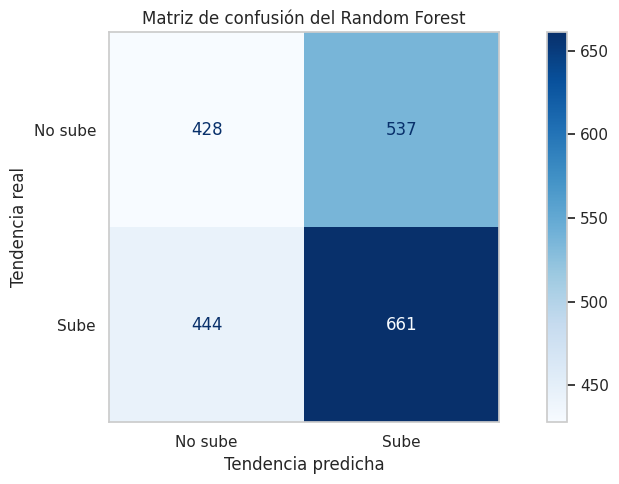

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Calcula y representa la matriz de confusión
matriz_confusion = confusion_matrix(y_test, y_pred)

visualizacion_matriz = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=["No sube", "Sube"]
)

visualizacion_matriz.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusión del Random Forest")
plt.xlabel("Tendencia predicha")
plt.ylabel("Tendencia real")
plt.grid(False)
plt.tight_layout()
plt.show()

## 17. Interpretación de predicciones e importancia

Se muestran algunos resultados del periodo de prueba y la importancia asignada por Random Forest a cada característica. La importancia no demuestra causalidad; solamente indica cuánto utilizó el modelo cada variable para separar los datos.

In [ ]:
# Construye una tabla para comparar tendencias reales y predichas
comparacion_predicciones = pd.DataFrame({
    "Fecha": fechas_test.reset_index(drop=True),
    "Tendencia_Real": y_test.reset_index(drop=True),
    "Tendencia_Predicha": y_pred
})

comparacion_predicciones["Acierto"] = (
    comparacion_predicciones["Tendencia_Real"]
    == comparacion_predicciones["Tendencia_Predicha"]
)

display(comparacion_predicciones.head(20))

,Fecha,Tendencia_Real,Tendencia_Predicha,Acierto
0,2015-03-13,1,1,True
1,2015-03-16,0,0,True
2,2015-03-17,1,1,True
3,2015-03-18,0,0,True
4,2015-03-19,1,0,False
5,2015-03-20,0,1,False
6,2015-03-23,0,0,True
7,2015-03-24,0,1,False
8,2015-03-25,0,0,True
9,2015-03-26,1,1,True


,Variable,Importancia
3,Cambio_Volumen,0.135472
4,Distancia_MM5,0.132996
5,Distancia_MM20,0.132073
0,Retorno_Diario,0.131590
2,Cambio_Intradiario,0.124054
7,Volatilidad_20,0.123528
1,Rango_Diario,0.115027
6,Volatilidad_5,0.105259


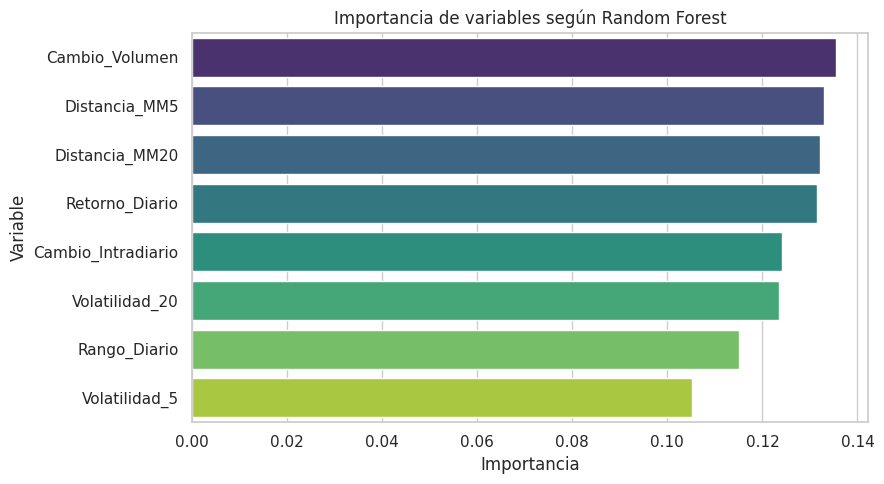

In [ ]:
# Ordena la importancia calculada para cada característica
importancia_variables = pd.DataFrame({
    "Variable": variables_independientes,
    "Importancia": modelo_rf.feature_importances_
}).sort_values("Importancia", ascending=False)

display(importancia_variables)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=importancia_variables,
    x="Importancia",
    y="Variable",
    hue="Variable",
    palette="viridis",
    legend=False
)

plt.title("Importancia de variables según Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 18. Conclusiones del segundo avance

- El problema fue formulado como aprendizaje supervisado de clasificación binaria utilizando **10,347 registros y 8 variables independientes**.
- La clase 1 representa una subida del cierre y constituye el **53.43 %** de los registros; la clase 0 representa una caída o mantenimiento y constituye el **46.57 %**.
- Se utilizaron **8,277 registros de 1982 a 2015** para entrenamiento y **2,070 registros de 2015 a 2023** para prueba, sin mezclar el orden temporal.
- Random Forest alcanzó **70.74 % de Accuracy en entrenamiento** y **52.61 % en prueba**, lo que muestra una reducción importante al evaluar datos posteriores y posible sobreajuste.
- La referencia que siempre predice la clase mayoritaria obtuvo **53.38 %**, por lo que el modelo todavía no proporciona una mejora predictiva sobre esa estrategia básica.
- El modelo obtuvo **55.18 % de Precision**, **59.82 % de Recall** y **57.40 % de F1**. Detectó 661 subidas y 428 días sin subida correctamente, pero produjo 537 falsos positivos y 444 falsos negativos.
- Cambio_Volumen, Distancia_MM5, Distancia_MM20 y Retorno_Diario fueron las características más utilizadas por el modelo, aunque su importancia no demuestra causalidad.
- El resultado no se considera un fracaso del procedimiento: demuestra que predecir la dirección diaria es difícil y justifica probar nuevas variables, otros modelos y validación temporal en los siguientes avances.

En el siguiente avance se podrá comparar este modelo con otra arquitectura e incorporar los componentes pendientes de PyTorch, NLP y Deep Learning.